# Poker as a decision-science sandbox: is the edge real?

A one-page visual tour. This project measures poker the way a quant measures a trading strategy. The question is not "did I win", it is "is the edge real, or is it noise". Each section below shows one headline figure and links to the notebook that reproduces it from committed data, with no retraining. The deliverable is the measurement discipline, not a poker bot.

Reading order: this overview, then notebooks 01 to 05 in order. Full narrative: [`../THESIS.md`](../THESIS.md). Sources with verification flags: [`../REFERENCES.md`](../REFERENCES.md).

In [1]:
import os
# Resolve the repo root whether the kernel starts in notebooks/ or the repo root.
ROOT = os.getcwd()
while not os.path.isdir(os.path.join(ROOT, "figures")) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
from IPython.display import Image, display
def show(name):
    display(Image(filename=os.path.join(ROOT, "figures", name)))
print("figures resolved under:", os.path.basename(ROOT))

figures resolved under: poker-simulation


## The whole project in one image

Every claimed edge as a point with its 95% bootstrap confidence interval. Two of the four straddle zero, and they are reported as unresolved. A fifth pre-registered result, the tilt-exploitation test, resolved negative and appears in Section 6.

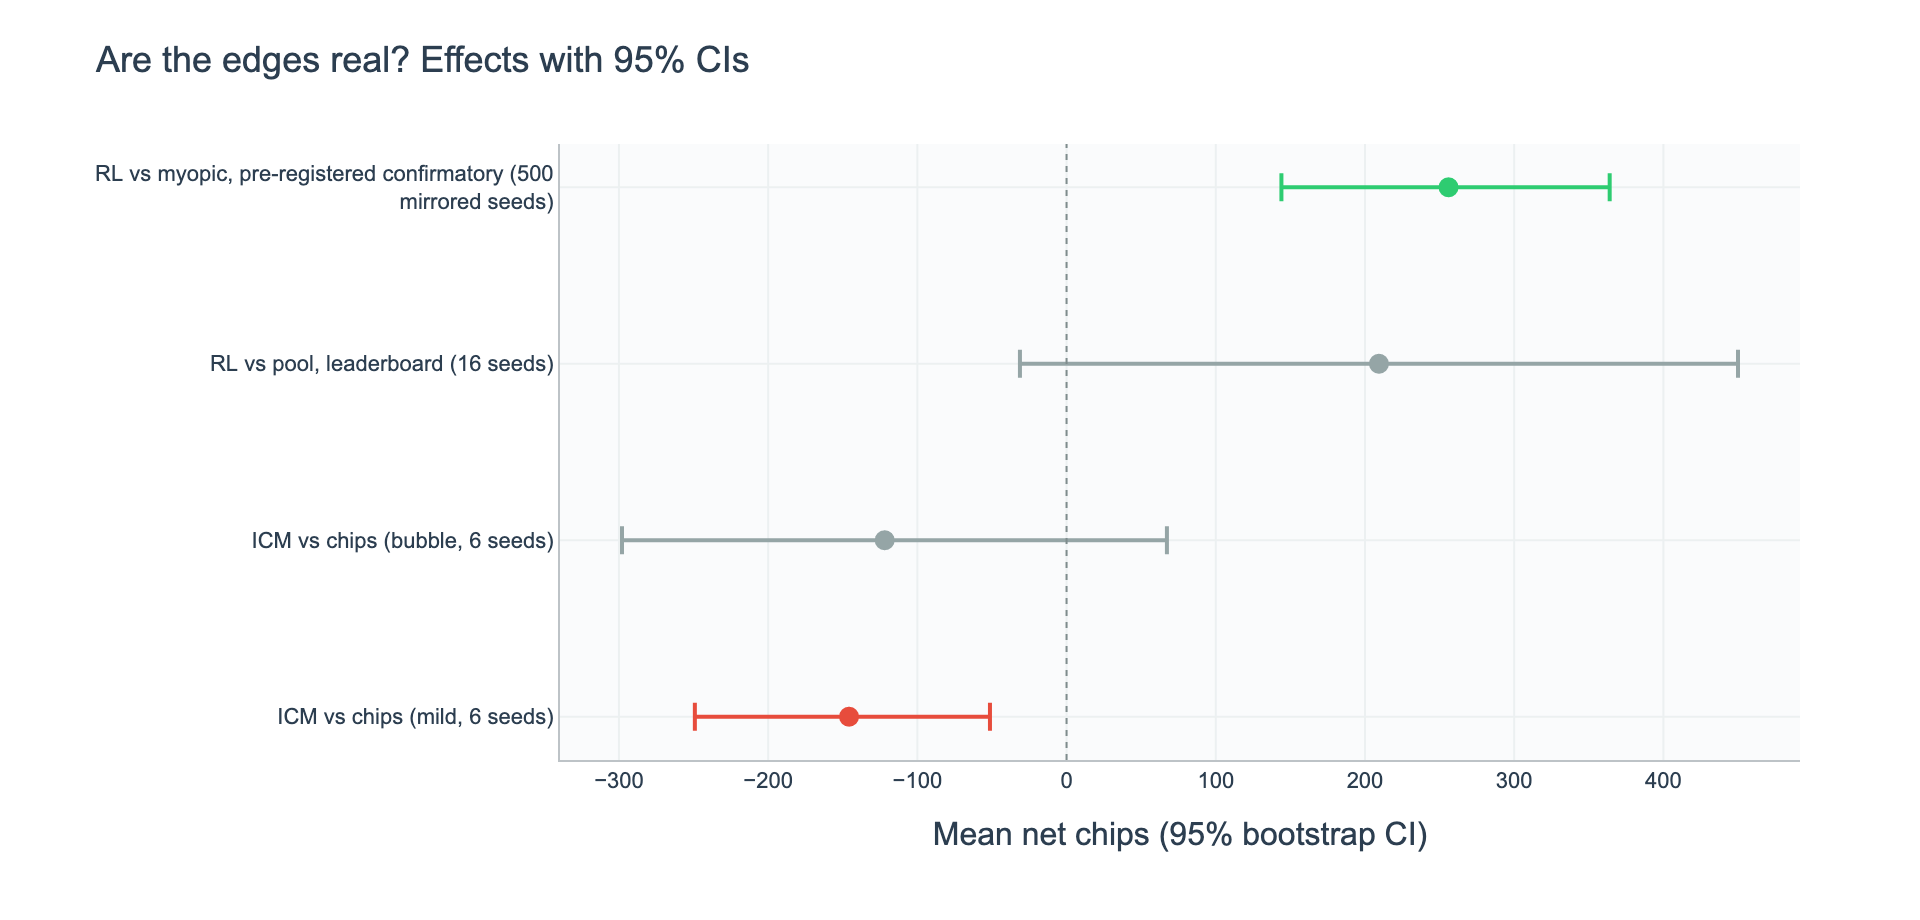

In [2]:
show('exec_summary.png')

## 1. Is the edge real? The headline, honestly bounded

The trained agent beats a myopic baseline by +256 chips per match under a pre-registered protocol (95% CI [+144, +364], binomial p approximately 7e-6). The same agent loses head-to-head to a zero-parameter analytic Kelly bot. Reporting both, and not over-sizing a modest edge, is the point. Reproduced in [01_evaluation_rigor.ipynb](01_evaluation_rigor.ipynb).

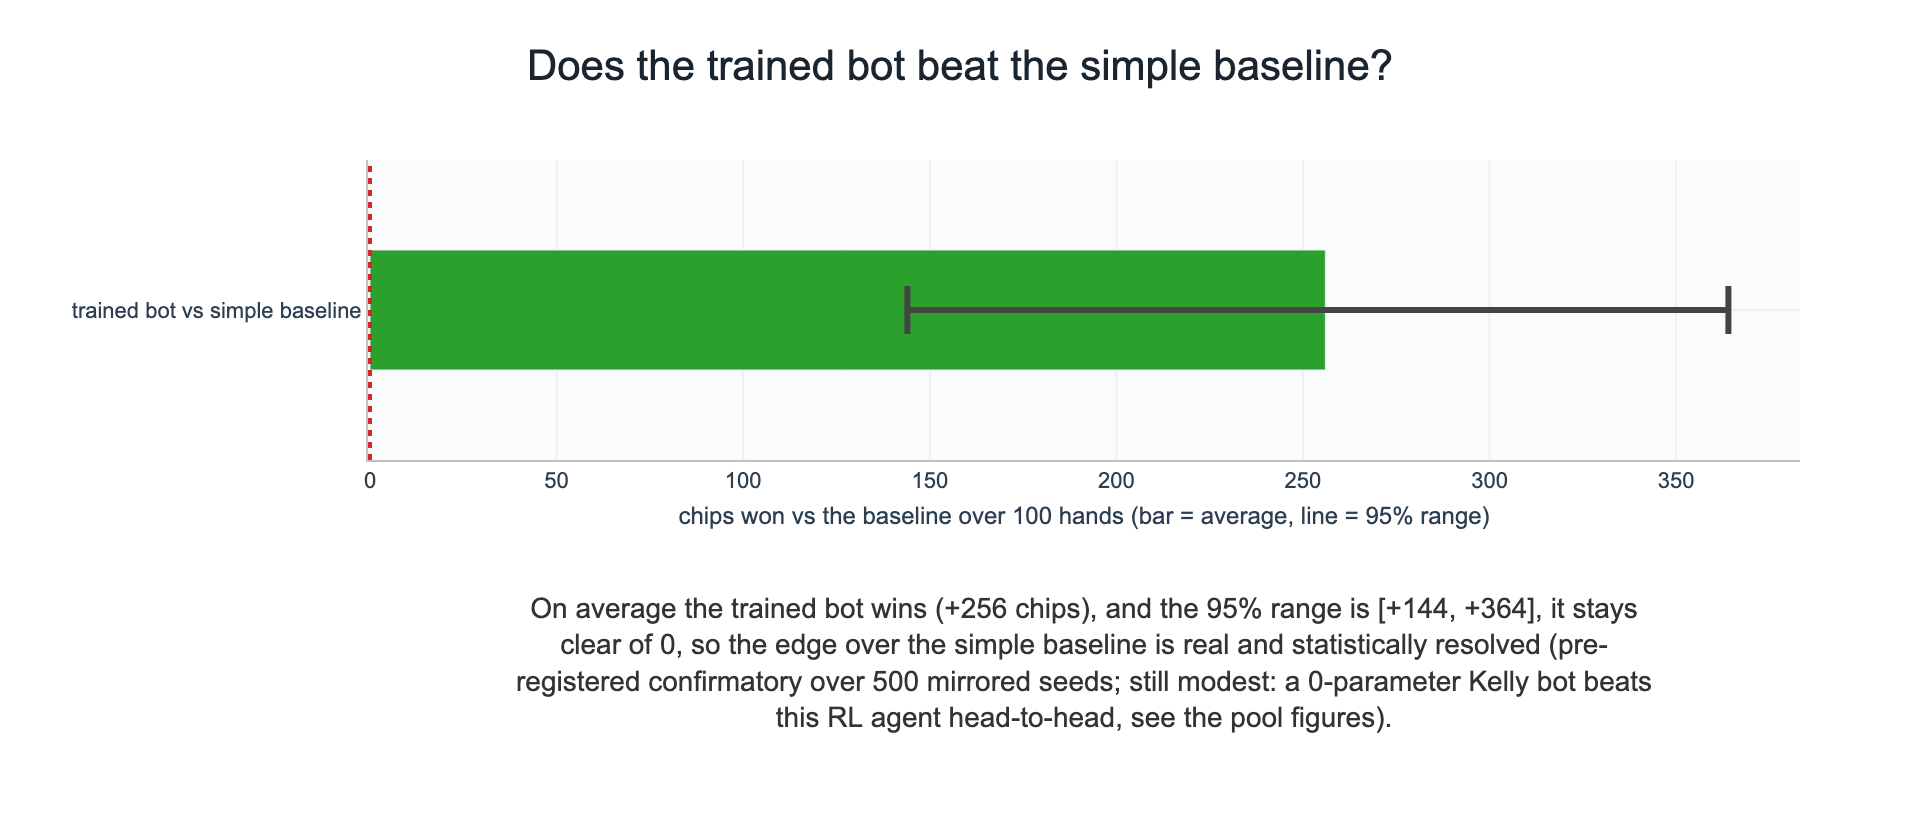

In [3]:
show('plain_rl_edge.png')

## 2. Ground truth: exact Nash on Leduc

With exact NashConv, the CFR time-average converges to 0.009, near Nash, while the greedy last-iterate, the regime a plain DQN lives in, stays exploitable around 2.2. This is the exact, verifiable reason self-play DQN does not reach equilibrium. Reproduced in [02_exploitability_leduc.ipynb](02_exploitability_leduc.ipynb).

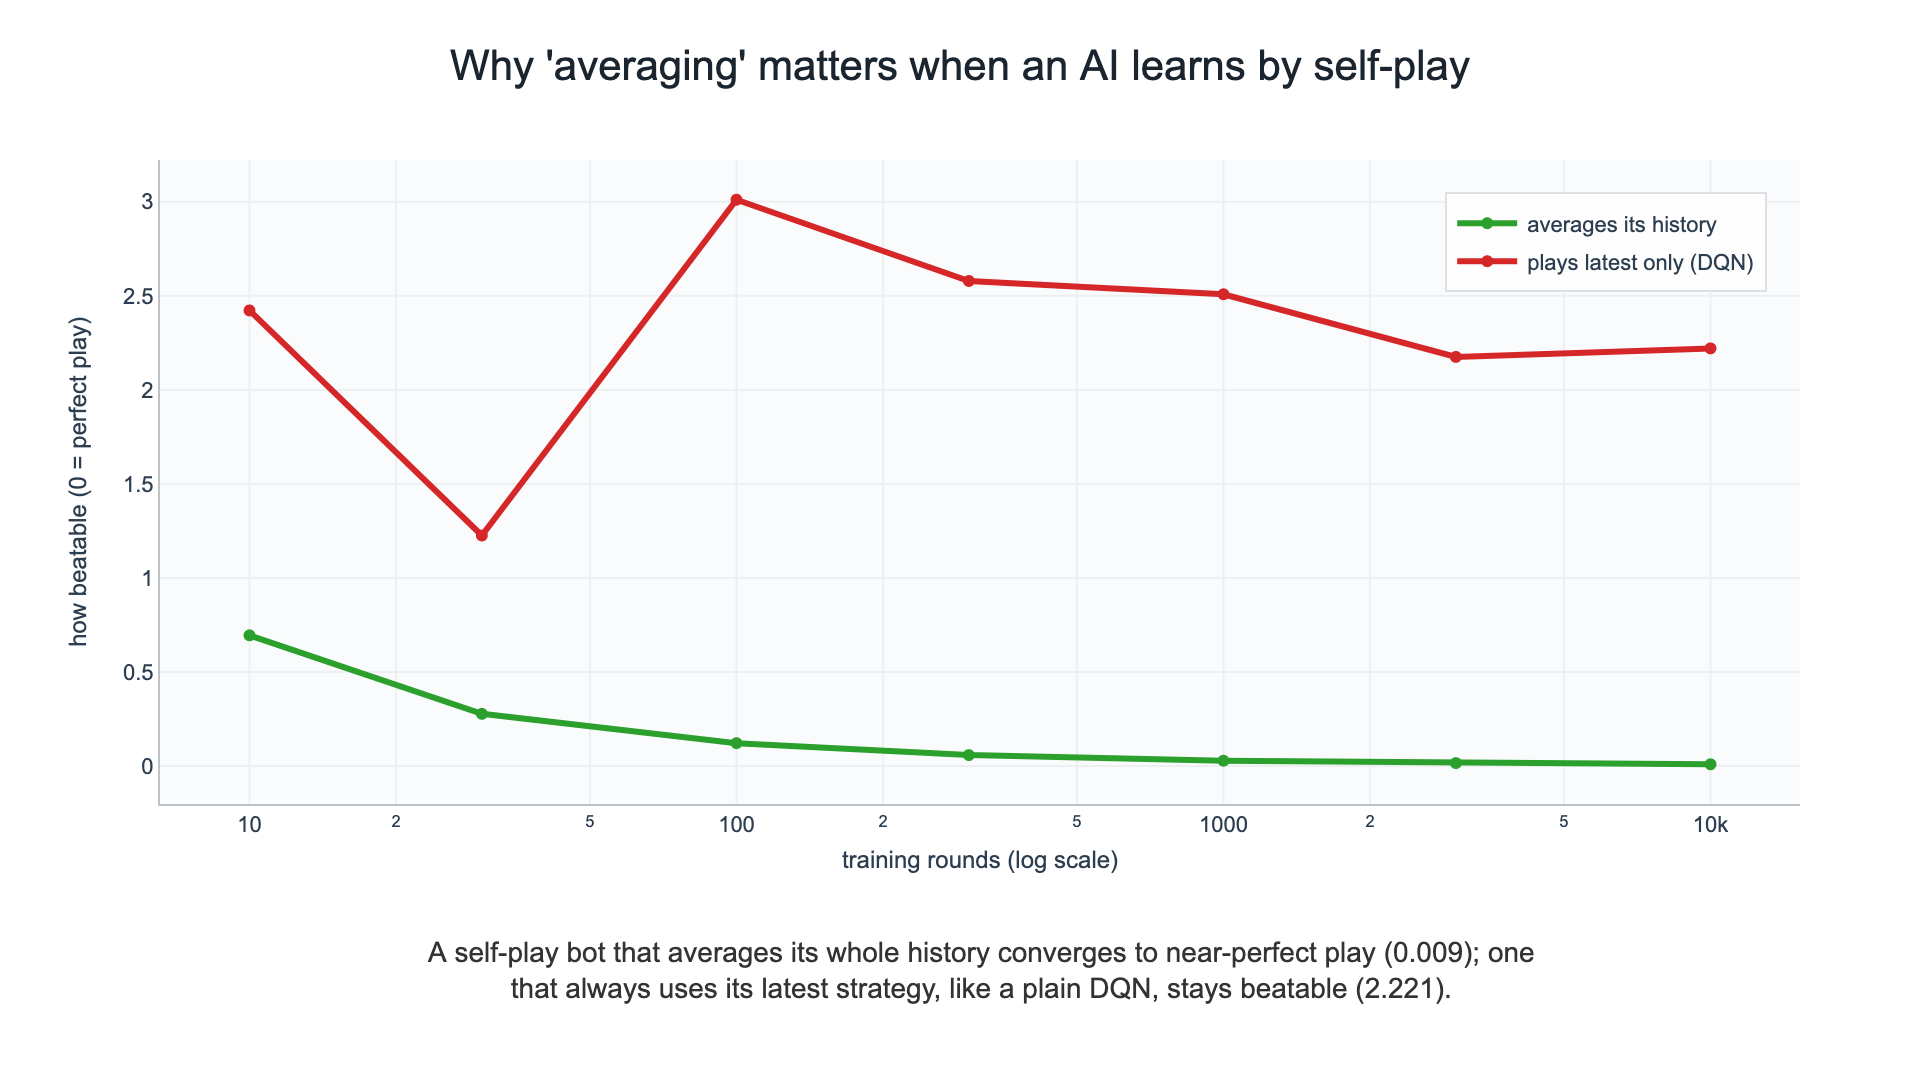

In [4]:
show('plain_nash.png')

## 3. The headline is robust, not a lucky seed (v2)

Retrained over 20 training seeds with the evaluation held identical, the per-seed edge is mean +351, median +300, across-seed 95% CI [+244, +468]. 16 of 20 seeds resolve a positive edge and none resolve negative. The published seed sits at the 35th percentile, below the median, so it was a conservative draw. Reproduced in [04_neural_scaling.ipynb](04_neural_scaling.ipynb).

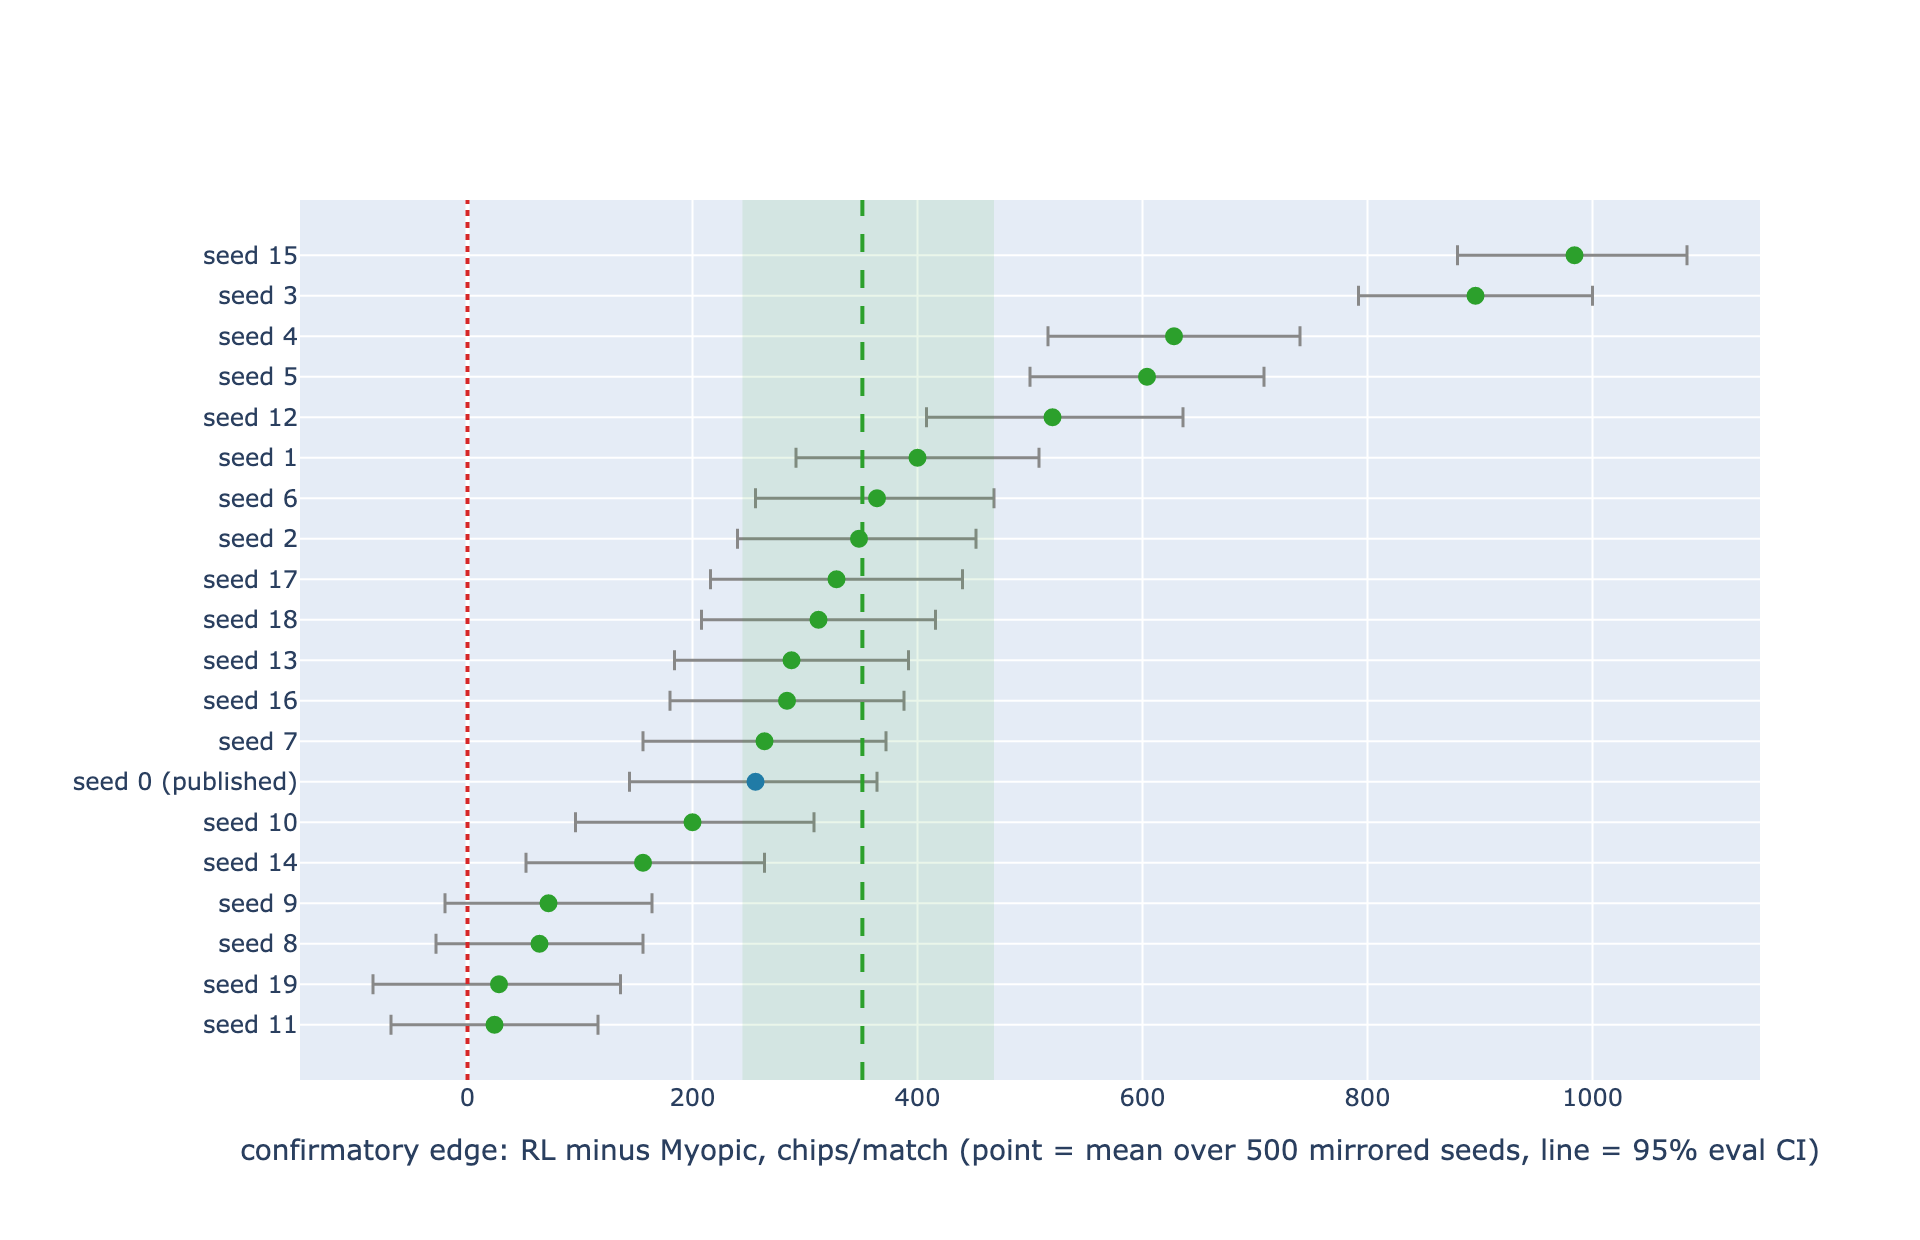

In [5]:
show('seed_sweep.png')

## 4. Neural methods and scaling: honest nulls (v2)

Neural NFSP only weakly beats tabular NFSP on small Leduc (a qualified 2-of-3 sample-efficiency result, and tabular still wins asymptotically). At R=20, where tabular CFR cannot converge in feasible time, truncated tabular CFR (0.253) still beats neural NFSP (1.004) at a matched budget (figure [`scale.png`](../figures/scale.png)). Neural equilibrium methods show no reliable edge at any scale this work can exactly evaluate. Reproduced in [04_neural_scaling.ipynb](04_neural_scaling.ipynb).

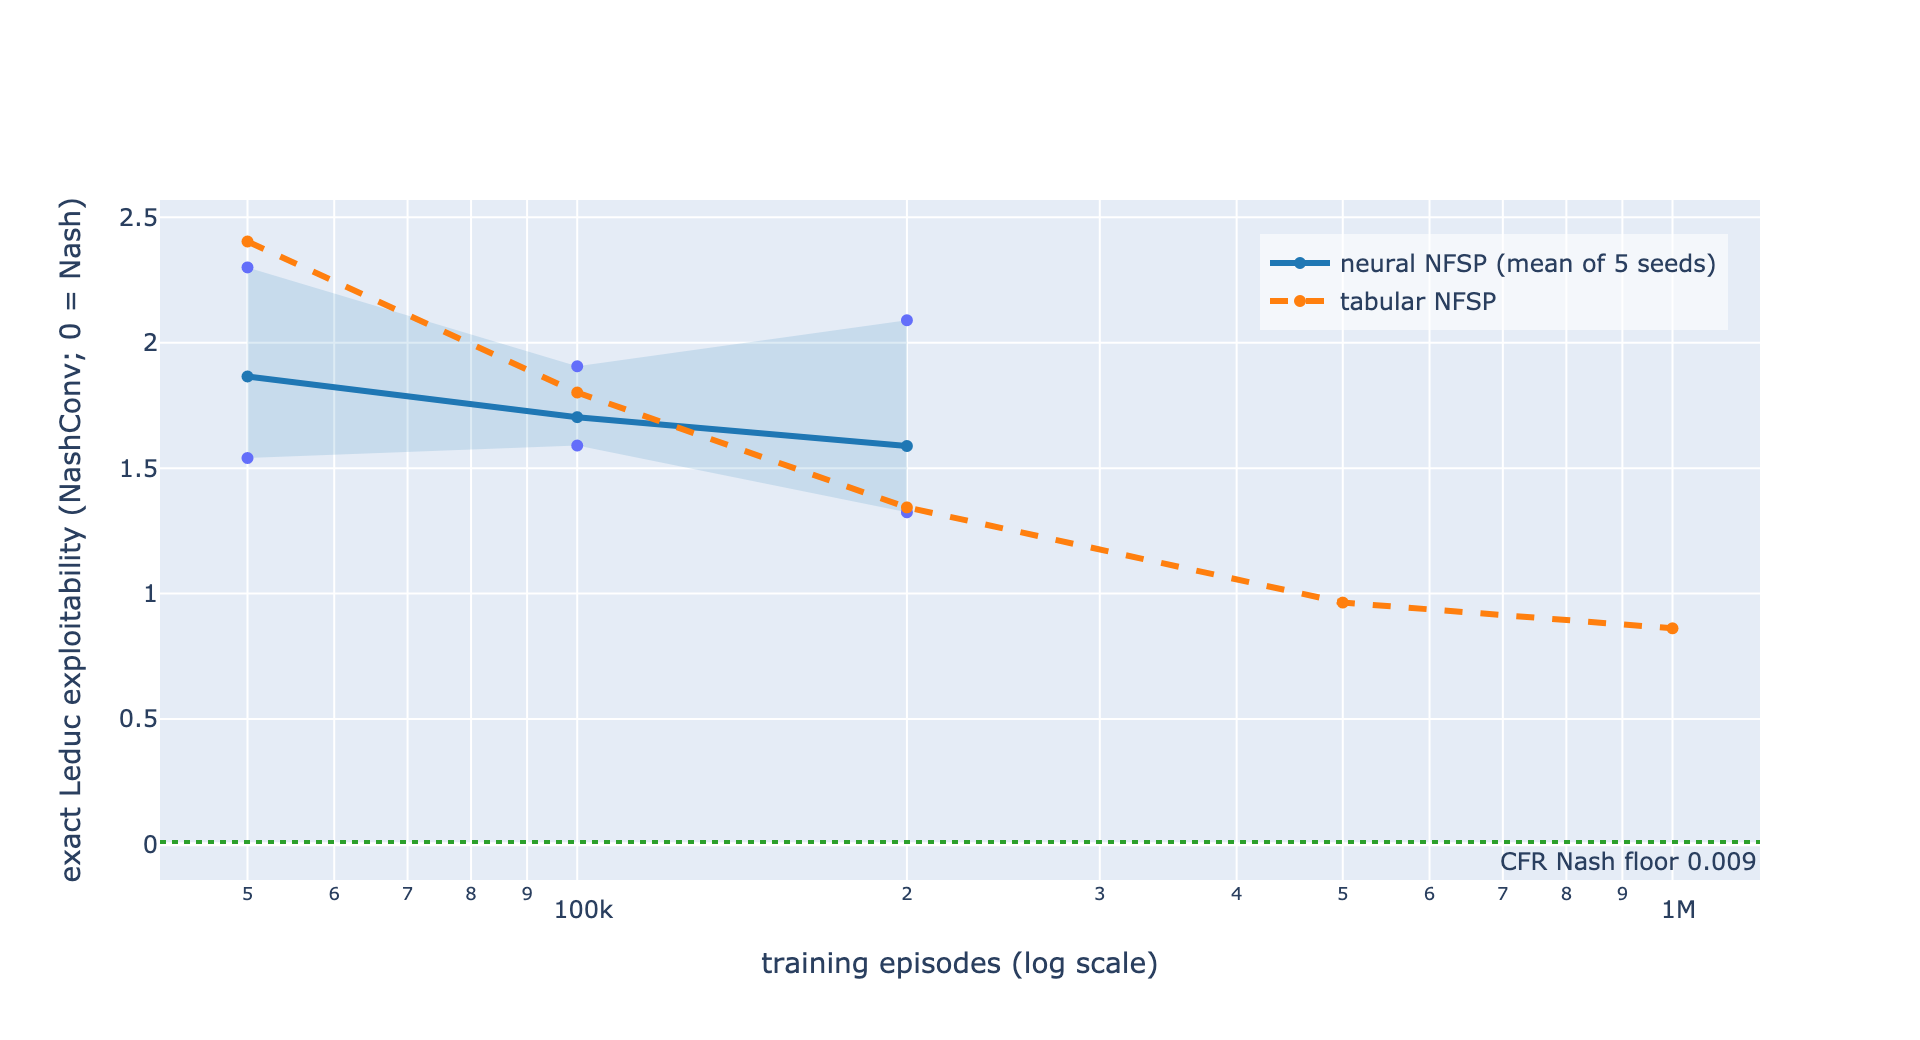

In [6]:
show('neural_nfsp.png')

## 5. Real humans tilt (777k hands)

On 777k real human hands, a within-player matched test (the hand after a loss against the hand after an equal-size win, same player) shows players turn +3.6pp more aggressive and +2.9pp looser after a loss (Cohen d 0.25 and 0.14, n=685). The shuffled-label placebo is near zero. This validates the opponent model only, never the policy. Reproduced in [03_realdata_tilt.ipynb](03_realdata_tilt.ipynb).

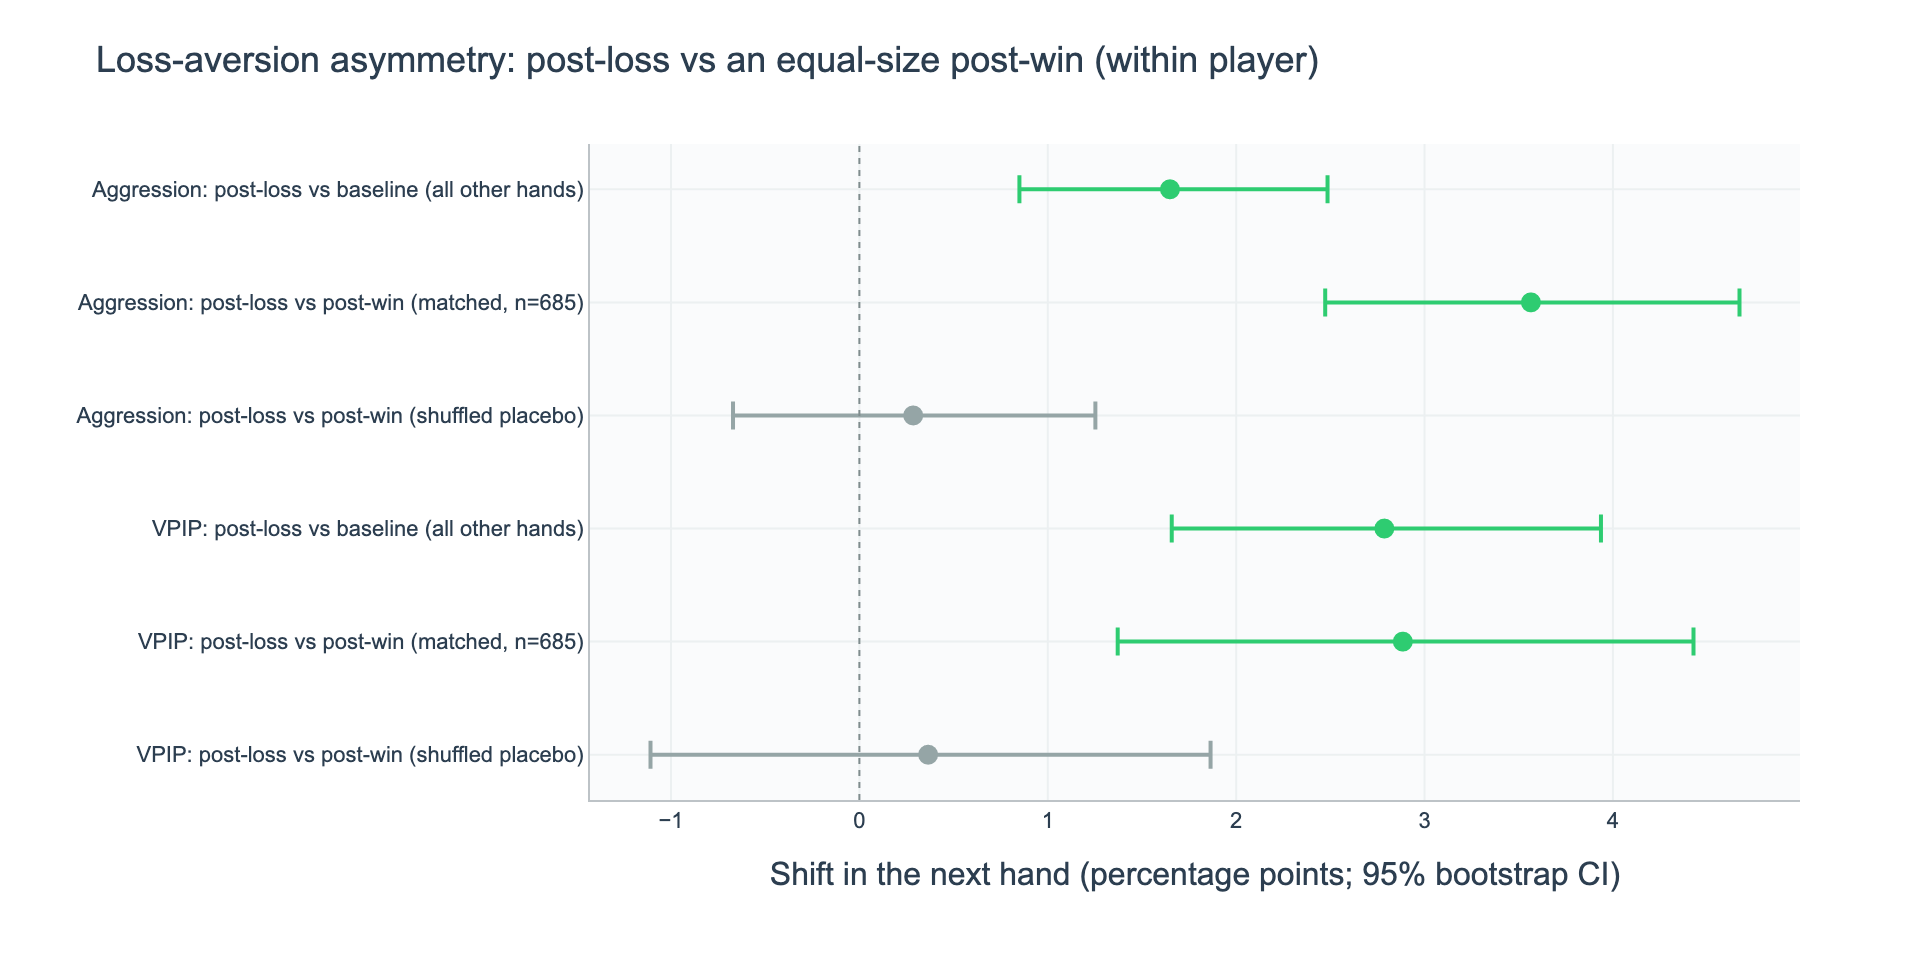

In [7]:
show('tilt_lossvswin.png')

## 6. Beyond Nash: a pre-registered exploitation negative (v2)

Conditioning the policy on a detected tilt signal was meant to earn EV. The pre-registered test resolved the other way: the knob loses 169 chips per match (95% CI [−271, −66], sign-test p approximately 0.04) against the tilter, because the disciplined baseline already beats it (+533) and loosening walks into its aggression. A small-sample peek had shown +152; the powered, pre-registered run overturned it. Reproduced in [05_exploitation.ipynb](05_exploitation.ipynb).

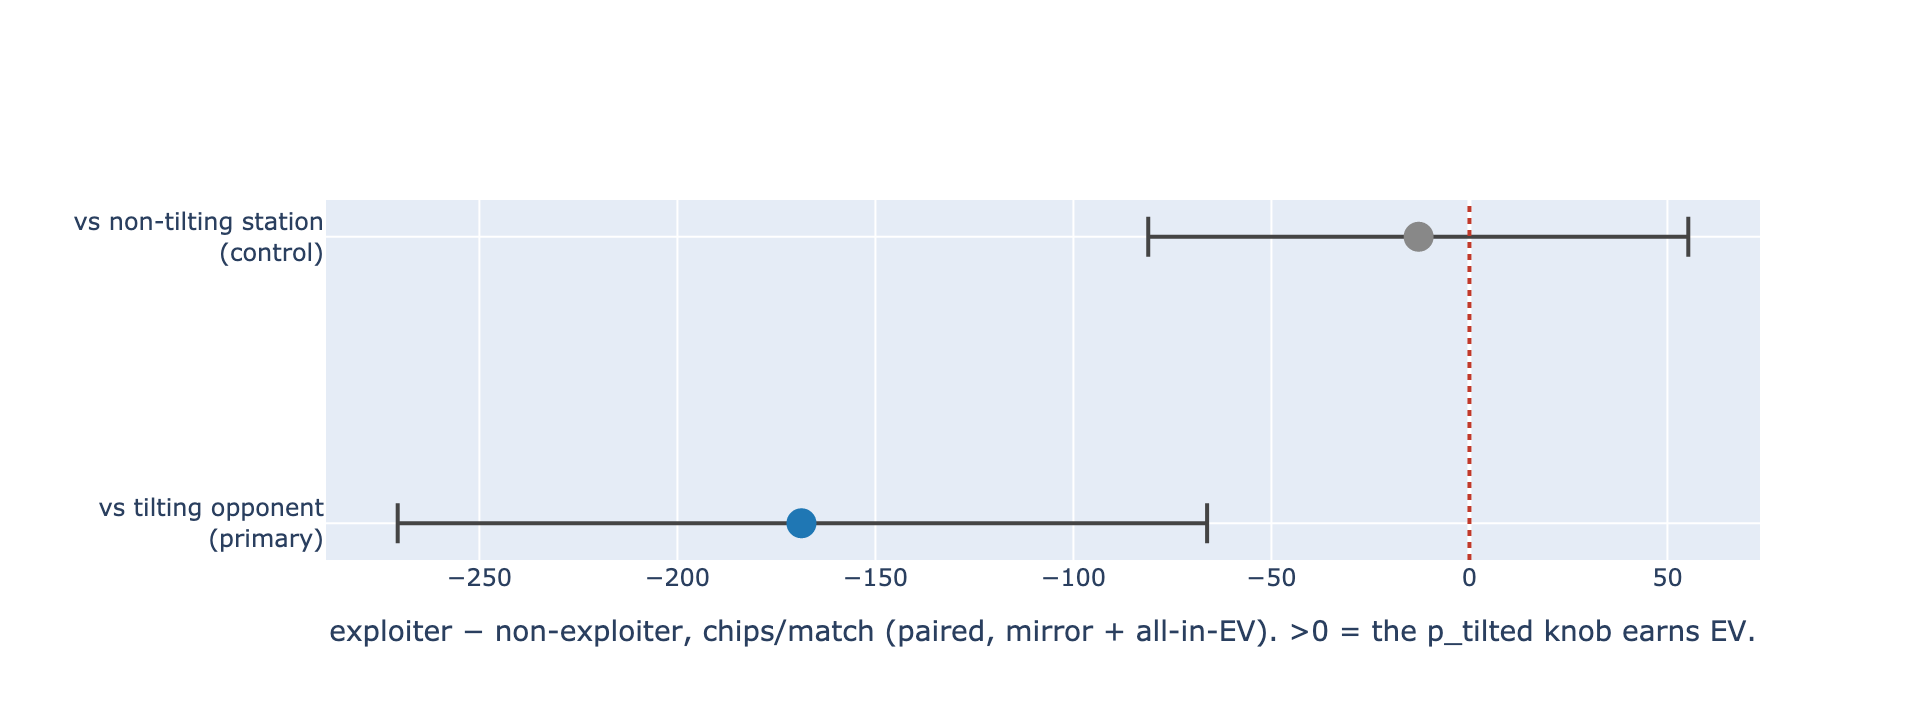

In [8]:
show('exploitation.png')

## 7. The reliable positive: exact exploitation on Leduc

The Section 6 attempt failed in the high-variance heads-up format. On Leduc, where EV is exact, a Restricted Nash Response (RNR) exploits every suboptimal opponent for a strictly positive, exactly-measured EV gain over Nash. The mixing parameter p traces the frontier from Nash (p=0, no exploitation and unexploitable) to the exact best response (p=1, maximum exploitation and maximally exploitable). Max gain over Nash: +0.96 (calling station), +2.16 (maniac), +1.50 (uniform) chips per deal, with zero sampling variance. Pre-registered (PREREGISTRATION.md §14).

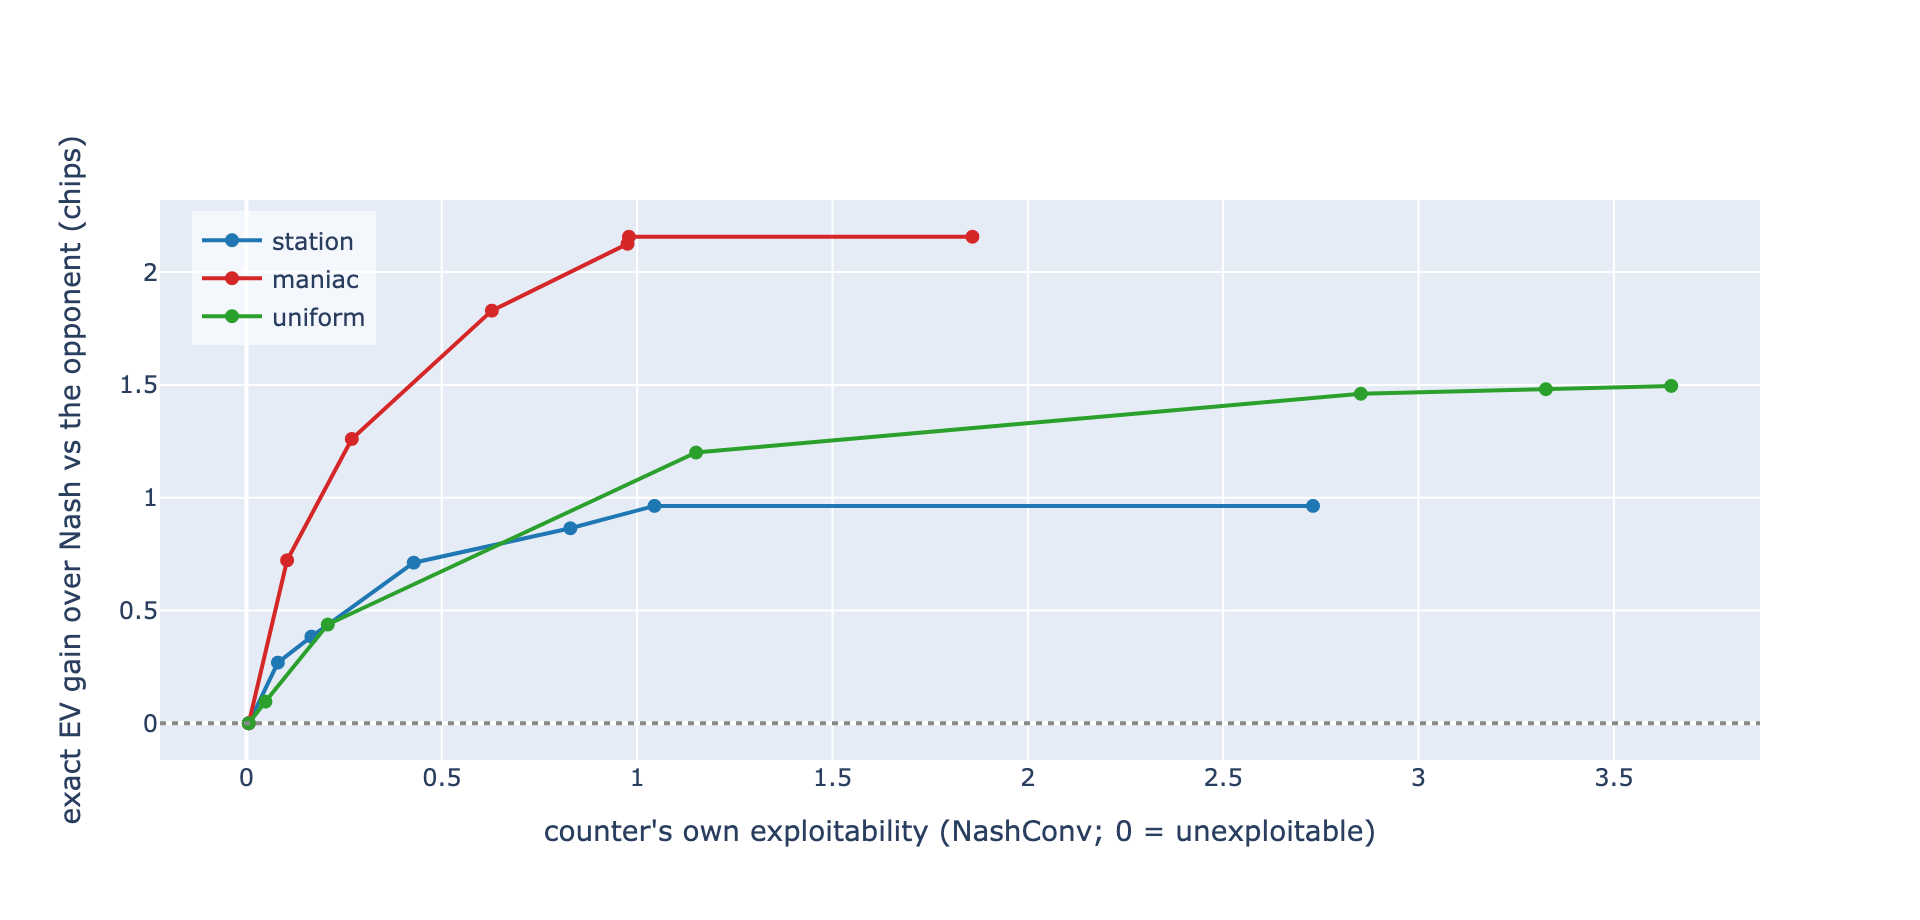

In [9]:
show('rnr_frontier.png')

## 8. The meaningful positive: exploitation that survives detection (v2)

Section 7 handed the algorithm the opponent's exact strategy, so its positive was guaranteed by construction. The honest question is whether exploitation survives when the opponent must be *learned*. Here the bot plays Nash, observes N hands, estimates the opponent as a frequency table, then runs the Restricted Nash Response on that estimate, scored by exact EV against the true opponent. With a conservative mixing (p=0.5) and 40 observed hands it beats Nash against all four opponents, each 95% CI excluding zero. The cautionary tale, dotted in the figure: a raw best response (p=1) to the always-raise maniac loses to Nash on average, because it best-responds to a too-sparsely-observed estimate and attacks a passivity that is not there. That is why a restricted response, not a raw one, is the right tool. Pre-registered (PREREGISTRATION.md §15). Reproduced in [05_exploitation.ipynb](05_exploitation.ipynb).

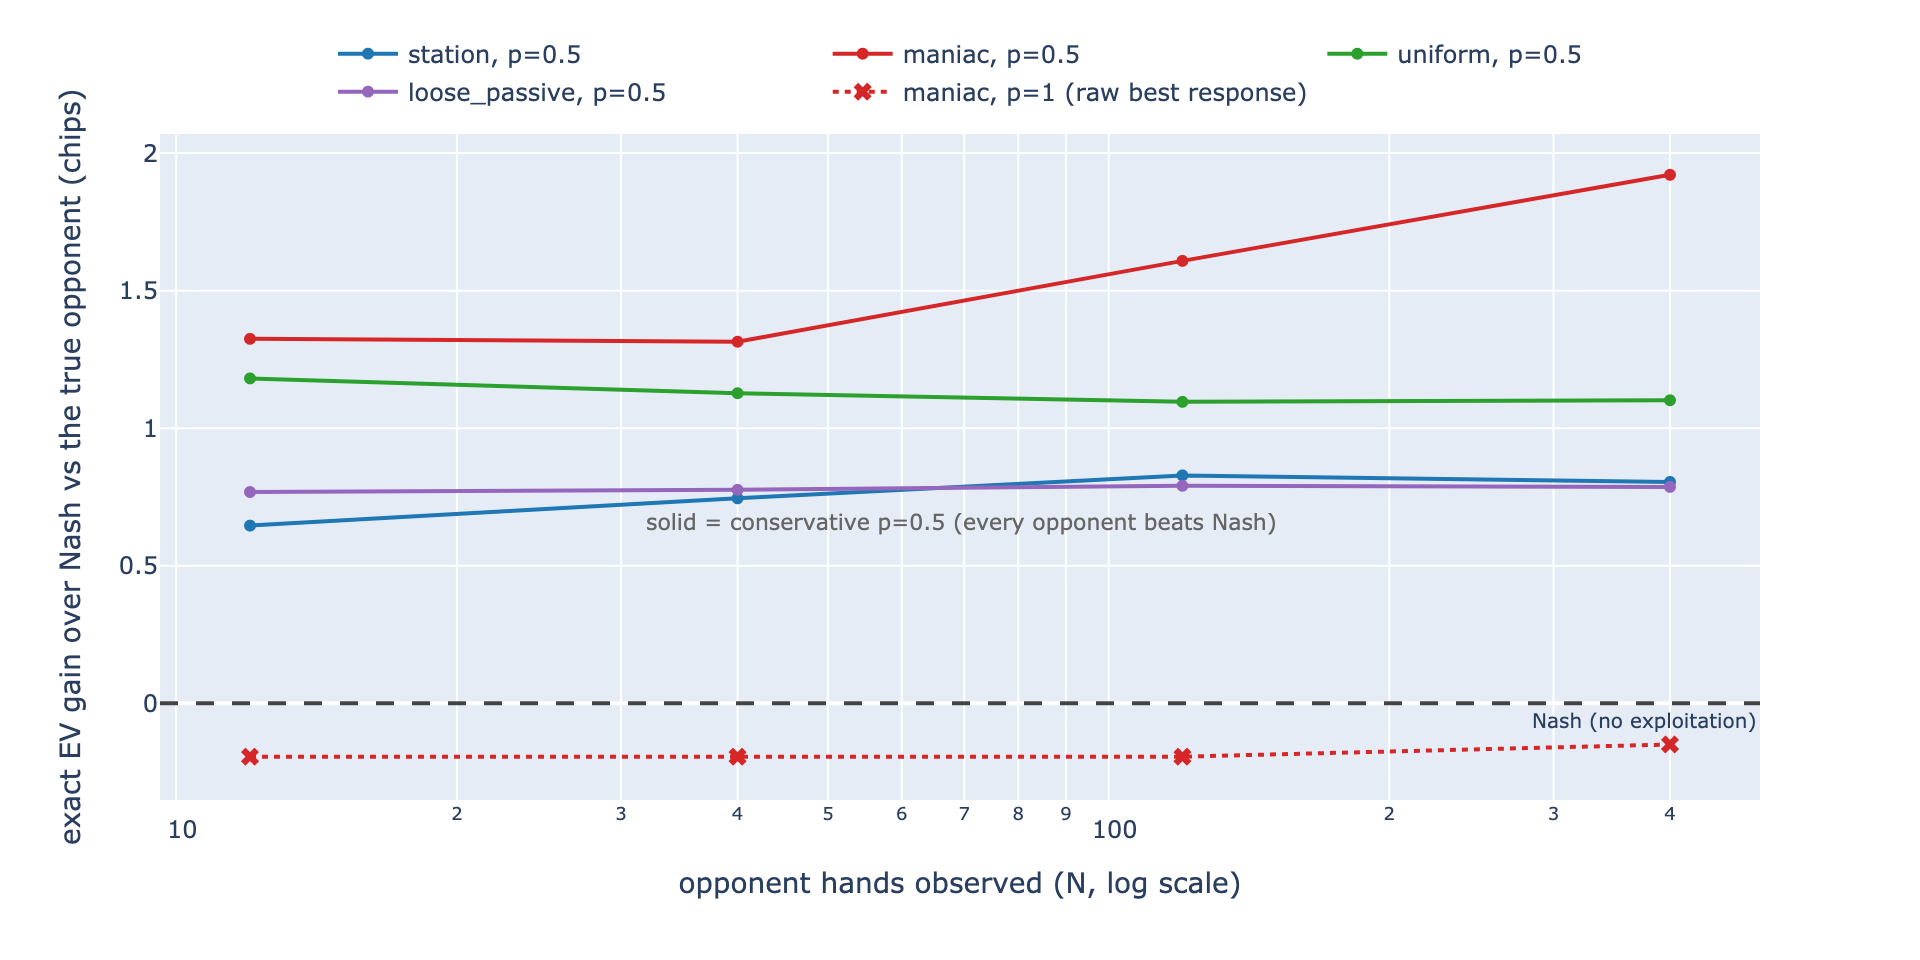

In [10]:
show('dbr_frontier.png')

## What I built, and why it matters

The reliable findings are a robustness confirmation, a set of clean nulls and negatives, and a two-step exploitation positive (Sections 7 and 8). The headline edge is robust to the training seed (Section 3). Neural equilibrium methods have no measurable edge at any scale this work can exactly evaluate (Section 4). A textbook tilt-exploitation counter-policy reliably backfires against an aggressive opponent (Section 6). And v2 turned that negative into a positive: on Leduc, where EV is exact, a Restricted Nash Response exploits every suboptimal opponent for a strictly positive, exactly-measured gain over Nash (Section 7); and when the opponent is no longer handed over but estimated from observed hands, a conservative response still beats Nash for every opponent, with the honest caveat that a raw best response to a sparsely-observed opponent can lose (Section 8).

The transferable skill is the method, which maps one-to-one onto quant research:

| In this project | The quant-research practice |
|---|---|
| Paired and mirror (duplicate-deck) seeds | Common-random-numbers backtesting |
| All-in EV control variate (AIVAT family) | Control variates for variance reduction |
| Bootstrap CIs and an exact sign test | Distribution-free significance for heavy-tailed PnL |
| Pre-registration with a freeze-then-result gap | Committing the test before the data, against p-hacking |
| Two-state {normal, tilted} HMM | Regime-switching models of a counterparty |
| Restricted response to an estimated opponent (RNR/DBR) | Sizing to a counterparty model you are only partly confident in |

Every number above traces to committed data under [`../results/`](../results/) and a figure under [`../figures/`](../figures/). The clearest single thread is the exploitation arc, Sections 6 to 8: a pre-registered attempt resolved negative, the two reasons it failed were fixed to reach an exact positive, and the positive then survived having to estimate the opponent from data, with its price and failure mode reported in full. The responsibility for the final content, analysis, and conclusions rests entirely with me.